In [2]:
# ─────────────────────────────────────────────
# [C1] ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율(양성 비율): {y.mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율(양성 비율): 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


── 혼동행렬 ─────────────────────────
[[2002   82]
 [ 186  196]]
TN(진음성) = 2,002   실제 비구매 → 비구매로 맞춤
FP(위양성) =    82   실제 비구매 → 구매로 오판  (헛된 마케팅비)
FN(위음성) =   186   실제 구매   → 비구매로 놓침 (매출 기회 손실)
TP(진양성) =   196   실제 구매   → 구매로 맞춤

── 평가지표 ─────────────────────────
정확도(Accuracy)  : 0.8913
정밀도(Precision) : 0.7050   → 구매라 예측한 것 중 실제 구매 비율
재현율(Recall)    : 0.5131   → 실제 구매자 중 잡아낸 비율
F1 Score          : 0.5939


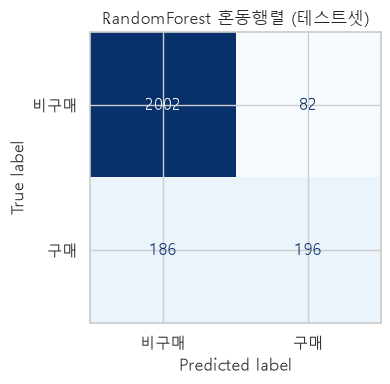

In [4]:
# [C2] 문제 1. 혼동행렬로 0.89를 쪼갠다
# ⌨️ 문제 1 — 정확도 하나를 네 칸으로 쪼개기
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, ConfusionMatrixDisplay)

# 여기에 코드를 작성하세요 (분리 → 학습 → 혼동행렬 → 지표 4종 → 놓친 사람 수)

# 1) 층화 분할 + 학습 -------------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

# 2) 혼동행렬 --------------------------------------------------------
cm = confusion_matrix(y_te, y_pred, labels=[0, 1])  # 행=실제, 열=예측
tn, fp, fn, tp = cm.ravel()                          # 순서 주의: TN FP FN TP

print("── 혼동행렬 ─────────────────────────")
print(cm)
print(f"TN(진음성) = {tn:5,d}   실제 비구매 → 비구매로 맞춤")
print(f"FP(위양성) = {fp:5,d}   실제 비구매 → 구매로 오판  (헛된 마케팅비)")
print(f"FN(위음성) = {fn:5,d}   실제 구매   → 비구매로 놓침 (매출 기회 손실)")
print(f"TP(진양성) = {tp:5,d}   실제 구매   → 구매로 맞춤")

# 3) 평가지표 --------------------------------------------------------
acc  = accuracy_score(y_te, y_pred)                       # (TP+TN)/전체
prec = precision_score(y_te, y_pred, zero_division=0)     # TP/(TP+FP)
rec  = recall_score(y_te, y_pred)                         # TP/(TP+FN)
f1   = f1_score(y_te, y_pred)                             # 정밀도·재현율 조화평균

print("\n── 평가지표 ─────────────────────────")
print(f"정확도(Accuracy)  : {acc:.4f}")
print(f"정밀도(Precision) : {prec:.4f}   → 구매라 예측한 것 중 실제 구매 비율")
print(f"재현율(Recall)    : {rec:.4f}   → 실제 구매자 중 잡아낸 비율")
print(f"F1 Score          : {f1:.4f}")

# 검산: 직접 계산해도 같은 값이 나옵니다
assert np.isclose(prec, tp / (tp + fp)) and np.isclose(rec, tp / (tp + fn))

# (보너스) 시각화
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["비구매", "구매"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("RandomForest 혼동행렬 (테스트셋)")
plt.tight_layout(); plt.show()


── 5-Fold 교차검증 (평균 ± 표준편차) ──────────────────
지표                  검증(test)              학습(train)             격차
----------------------------------------------------------------------
accuracy            0.8969 ± 0.0034     0.9168 ± 0.0010     +0.0199
precision           0.7232 ± 0.0117     0.8045 ± 0.0048     +0.0813
recall              0.5409 ± 0.0241     0.6111 ± 0.0119     +0.0702
f1                  0.6186 ± 0.0175     0.6945 ± 0.0066     +0.0759
average_precision   0.7248 ± 0.0191     0.8089 ± 0.0027     +0.0842
roc_auc             0.9091 ± 0.0081     0.9510 ± 0.0013     +0.0419

── 폴드별 F1 / AP ─────────────────────
          f1  average_precision  roc_auc
fold1 0.6193             0.7400   0.9224
fold2 0.6092             0.6957   0.8998
fold3 0.6342             0.7355   0.9062
fold4 0.6394             0.7441   0.9137
fold5 0.5909             0.7086   0.9033

── AP 해석 ────────────────────────────
양성 비율(=AP 기준선) : 0.1547
모델 AP               : 0.7248
기준선 대비 배수       : 4.68배
ROC-AUC 

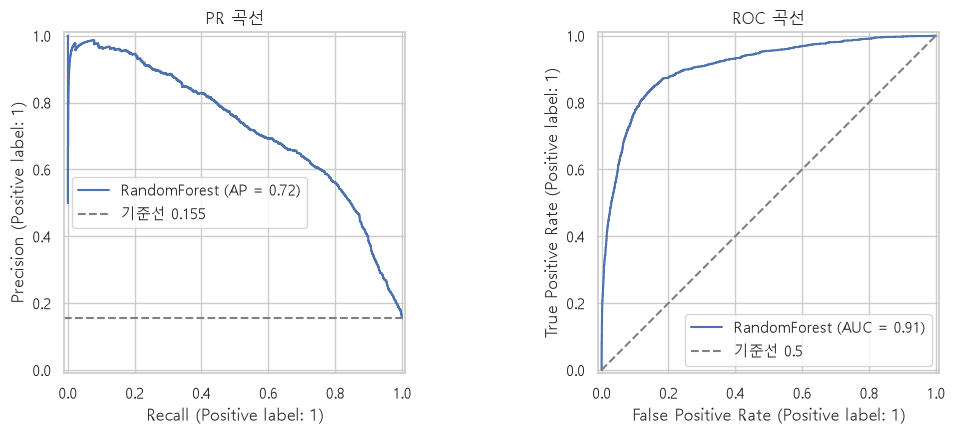

In [ ]:
# [C3] 문제 2. 지표 5종을 교차 검증으로 한 번에 잰다
# ⌨️ 문제 2 — cross_validate로 다섯 지표를 동시에
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score

# 여기에 코드를 작성하세요 (5겹 CV로 지표 5종 → 평균±표준편차 → 기준선 대비)

# 1) 스코어러 딕셔너리 --------------------------------------------------
#    average_precision과 roc_auc는 predict가 아니라 predict_proba를 씁니다
#    (cross_validate가 알아서 호출해 줍니다)
SCORING = {
    "accuracy":          "accuracy",
    "precision":         "precision",
    "recall":            "recall",
    "f1":                "f1",
    "average_precision": "average_precision",  # PR 곡선 아래 면적(AP)
    "roc_auc":           "roc_auc",            # 3)번 참고용으로 같이 넣습니다
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cv = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                               random_state=RANDOM_STATE, n_jobs=-1)

cv_res = cross_validate(rf_cv, X, y, cv=cv, scoring=SCORING,
                        return_train_score=True, n_jobs=-1)

# 2) 평균 ± 표준편차 ---------------------------------------------------
print("── 5-Fold 교차검증 (평균 ± 표준편차) ──────────────────")
print(f"{'지표':<20}{'검증(test)':<22}{'학습(train)':<22}{'격차'}")
print("-" * 70)

rows = {}
for name in SCORING:
    te = cv_res[f"test_{name}"]
    tr = cv_res[f"train_{name}"]
    rows[name] = te
    print(f"{name:<20}"
          f"{te.mean():.4f} ± {te.std():.4f}     "
          f"{tr.mean():.4f} ± {tr.std():.4f}     "
          f"{tr.mean() - te.mean():+.4f}")

# 폴드별 원시값도 확인 (안정성 판단용)
print("\n── 폴드별 F1 / AP ─────────────────────")
pd.set_option("display.float_format", "{:.4f}".format)
print(pd.DataFrame({"f1": rows["f1"],
                    "average_precision": rows["average_precision"],
                    "roc_auc": rows["roc_auc"]},
                   index=[f"fold{i+1}" for i in range(cv.get_n_splits())]))

# 3) AP를 양성 비율(=랜덤 기준선)과 비교 --------------------------------
baseline_ap = y.mean()          # PR 곡선의 기준선은 양성 비율
ap          = rows["average_precision"].mean()
auc         = rows["roc_auc"].mean()

print("\n── AP 해석 ────────────────────────────")
print(f"양성 비율(=AP 기준선) : {baseline_ap:.4f}")
print(f"모델 AP               : {ap:.4f}")
print(f"기준선 대비 배수       : {ap / baseline_ap:.2f}배")
print(f"ROC-AUC (기준선 0.50) : {auc:.4f}")

# (보너스) PR 곡선 — 기준선을 눈으로 확인
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

proba = cross_val_predict(rf_cv, X, y, cv=cv, method="predict_proba",
                          n_jobs=-1)[:, 1]                                  # proba는 [비구매확률, 구매확률]을 나타냄

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
PrecisionRecallDisplay.from_predictions(y, proba, ax=axes[0], name="RandomForest")
axes[0].axhline(baseline_ap, ls="--", c="gray",
                label=f"기준선 {baseline_ap:.3f}")
axes[0].set_title("PR 곡선"); axes[0].legend()

RocCurveDisplay.from_predictions(y, proba, ax=axes[1], name="RandomForest")
axes[1].plot([0, 1], [0, 1], ls="--", c="gray", label="기준선 0.5")
axes[1].set_title("ROC 곡선"); axes[1].legend()
plt.tight_layout(); plt.show()

1. AP의 기준선은 양성(15%)이므로 절대값만 보면 별로 안 높아보이지만 기준선 대비 4.68배 높으므로 꽤 좋다고 판단할 수 있다.
2. 불균형데이터에서는 AP가 보수적으로 나온다. ROC는 x축에 FPR로 실제 음성인 사람을 대상으로 하기 때문에 불균형데이터에서는 ROC가 실제보다 더 좋게 나온다
  - 반면 AP는 TP+FP라 FP증가에 바로 반응한다. 마케팅비를 고르는 문제라면 AP쪽을 더 관심있게 봐야한다.
3. 값이 저렇게 흔들리는 이유는 (폴드에서) 양성값이 부족해서임
 - AP는 ROC 순위를 따라감, 하지만 f1-score는 그렇지 않음 AP와 ROC는 모든 임계값을 평균하지만 f1-score는 0.5 한 지점에서만 본다
 0.48~0.52에서 애매하게 걸친 세션들에 따라 흔들린다.

── 임계값별 지표 ────────────────────────────
 threshold  n_positive_pred  precision  recall     f1
    0.1000             3615     0.4606  0.8726 0.6029
    0.1500             3050     0.5200  0.8312 0.6398
    0.2000             2801     0.5512  0.8092 0.6558
    0.2500             2606     0.5748  0.7851 0.6637
    0.3000             2448     0.5944  0.7626 0.6680
    0.3500             2227     0.6215  0.7254 0.6694
    0.4000             1984     0.6562  0.6824 0.6691
    0.4500             1715     0.6863  0.6169 0.6497
    0.5000             1427     0.7232  0.5409 0.6189
    0.5500             1195     0.7732  0.4843 0.5956
    0.6000              995     0.8161  0.4256 0.5594
    0.6500              819     0.8437  0.3622 0.5068
    0.7000              659     0.8862  0.3061 0.4550

── F1 최적 임계값 ──
threshold=0.35  (precision=0.6215, recall=0.7254, f1=0.6694, 양성예측=2,227건)
(0.01 간격 정밀 탐색 결과: threshold=0.36, f1=0.6699)

── 쿠폰 500장 제약 역산 ──
필요 임계값        : 0.7584
실제 선정 건수      : 500건
정밀

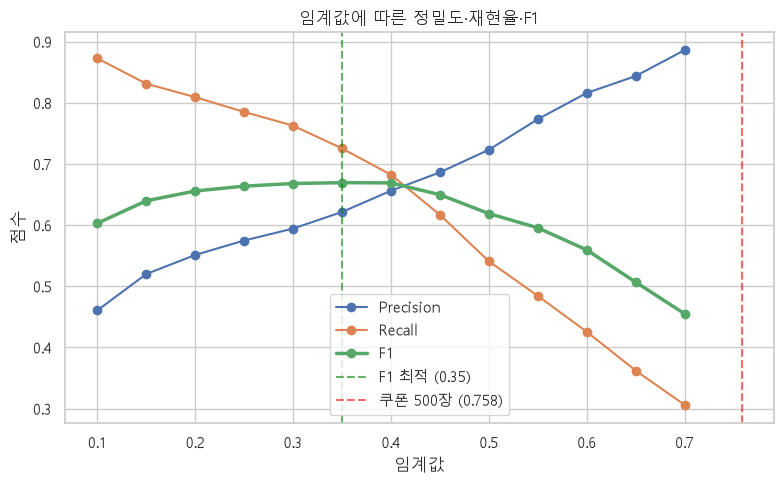

In [6]:
# ─────────────────────────────────────────────
# [C5] 🎚️ 임계값 스윕 → 최적 F1 → "쿠폰 500장" 역산
# ─────────────────────────────────────────────
# proba는 [C3]에서 만든 교차검증 out-of-fold 확률을 그대로 씁니다.
# (실제 배포 없이도 "안 본 데이터에 대한 예측"과 같은 성격이라 임계값 튜닝에 적합합니다)

# 1) 임계값 스윕 -------------------------------------------------------
thresholds = np.round(np.arange(0.10, 0.71, 0.05), 2)

records = []
for t in thresholds:
    pred_t = (proba >= t).astype(int)                           # 임계값 t 이상이면 양성(1), 아니면 음성(0)으로 예측
    n_pos  = pred_t.sum()                                       # 양성으로 예측된 건수(=쿠폰 발급 대상)
    p      = precision_score(y, pred_t, zero_division=0)        # 임계값이 너무 높아서 양성예측이 0이되면 에러대신 0을 반환하도록하는 안전장치
    r      = recall_score(y, pred_t, zero_division=0)
    f      = f1_score(y, pred_t, zero_division=0)
    records.append([t, n_pos, p, r, f])

sweep = pd.DataFrame(records,
                     columns=["threshold", "n_positive_pred",
                              "precision", "recall", "f1"])
print("── 임계값별 지표 ────────────────────────────")
print(sweep.to_string(index=False, float_format="%.4f"))

# 2) F1 최대 임계값 -----------------------------------------------------
best_row = sweep.loc[sweep["f1"].idxmax()]
print(f"\n── F1 최적 임계값 ──")
print(f"threshold={best_row.threshold:.2f}  "
      f"(precision={best_row.precision:.4f}, recall={best_row.recall:.4f}, "
      f"f1={best_row.f1:.4f}, 양성예측={int(best_row.n_positive_pred):,}건)")

# 참고: 0.05 간격보다 촘촘하게 찾으면 살짝 다른 값이 나올 수 있습니다
fine_t = np.round(np.arange(0.05, 0.951, 0.01), 2)
fine_f1 = [f1_score(y, (proba >= t).astype(int), zero_division=0) for t in fine_t]
best_fine_t = fine_t[np.argmax(fine_f1)]
print(f"(0.01 간격 정밀 탐색 결과: threshold={best_fine_t:.2f}, "
      f"f1={max(fine_f1):.4f})")

# 3) "쿠폰 500장" 제약 → 임계값 역산 --------------------------------
# 상위 500건만 뽑는 것 = 확률을 내림차순 정렬했을 때 500번째 값을 임계값으로 쓰는 것
N_COUPON = 500

sorted_proba = np.sort(proba)[::-1]           # 내림차순
# 500번째로 높은 확률값을 임계값으로 쓰면 그 값 "이상"인 건수가 500건이 됩니다
threshold_500 = sorted_proba[N_COUPON - 1]

pred_500 = (proba >= threshold_500).astype(int)
n_selected = pred_500.sum()

print(f"\n── 쿠폰 500장 제약 역산 ──")
print(f"필요 임계값        : {threshold_500:.4f}")
print(f"실제 선정 건수      : {n_selected:,}건")  # 동률(확률이 같은 값)이 있으면 500보다 클 수 있음
print(f"정밀도(Precision)  : {precision_score(y, pred_500):.4f}  "
      f"→ 쿠폰 준 500명 중 실제 구매 전환 예정 비율")
print(f"재현율(Recall)     : {recall_score(y, pred_500):.4f}  "
      f"→ 전체 구매 예정자 중 이 500명이 커버하는 비율")
print(f"F1                 : {f1_score(y, pred_500):.4f}")

if n_selected > N_COUPON:
    print(f"\n⚠ 확률 동률로 {n_selected - N_COUPON}건이 초과 선정됐습니다.")
    print("  정확히 500장만 필요하면 np.argsort로 순위를 매겨 상위 500개 인덱스만 뽑으세요:")
    print("  top_idx = np.argsort(-proba)[:500]")

# (보너스) 두 임계값을 표에서 한눈에 비교
compare = pd.DataFrame({
    "기준": ["F1 최적", "쿠폰 500장"],
    "threshold": [best_row.threshold, threshold_500],
    "양성예측건수": [int(best_row.n_positive_pred), int(n_selected)],
    "precision": [best_row.precision, precision_score(y, pred_500)],
    "recall": [best_row.recall, recall_score(y, pred_500)],
})
print("\n── 비교 ──")
print(compare.to_string(index=False, float_format="%.4f"))

# (보너스) 시각화
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(sweep.threshold, sweep.precision, "o-", label="Precision")
ax1.plot(sweep.threshold, sweep.recall, "o-", label="Recall")
ax1.plot(sweep.threshold, sweep.f1, "o-", label="F1", lw=2.5)
ax1.axvline(best_row.threshold, ls="--", c="green", alpha=0.6,
           label=f"F1 최적 ({best_row.threshold:.2f})")
ax1.axvline(threshold_500, ls="--", c="red", alpha=0.6,
           label=f"쿠폰 500장 ({threshold_500:.3f})")
ax1.set_xlabel("임계값"); ax1.set_ylabel("점수")
ax1.set_title("임계값에 따른 정밀도·재현율·F1")
ax1.legend(); plt.tight_layout(); plt.show()

- 임계값이 0.7584인 이유 : 확률을 크기순으로 세웠을때 500등에 해당하는 사람의 확률이 0.7584
- 마케팅적 관점 : 예산이 500장 한정이라면 임계값을 확 높였을때 당연히 재현율은 올라갈 수 밖에 없다 하지만 여기에는 함정이 있음
    쿠폰의 가치는 **안 살 사람에게 쿠폰을 줘서 살 사람으로 전환**이 중요한데 정밀도 91%가 의미하는건 어차피 살 사람들에게 쿠폰을 주는것 - 이를 잠식효과라고 부름
    이 문제를 다루는건 uplifting modeling, 인과추론 기반 타겟팅 이다
    구매확률이 아니라 **쿠폰을 받았을때와 받지 않았을때의 구매확률차이**를 예측하는것
    DiD와 인과추론과 연결되어있음
    확률이 높지도 낮지도 않은 중간 지점 사람들에게 오히려 쿠폰 효과가 가장 클 수 있다

── class_weight='balanced' 5-Fold 교차검증 ──────────
accuracy            0.8646 ± 0.0051
precision           0.5415 ± 0.0109
recall              0.8202 ± 0.0234
f1                  0.6522 ± 0.0125
average_precision   0.7176 ± 0.0158
roc_auc             0.9094 ± 0.0078

(참고) balanced 가중치: 음성(비구매)=0.5915, 양성(구매)=3.2311
       → 양성 1건이 음성 5.46건만큼의 무게로 학습됩니다

── 기본 vs balanced 비교 (교차검증) ──────────────────
               지표  기본_평균  기본_표준편차  balanced_평균  balanced_표준편차      변화
         accuracy 0.8969   0.0034       0.8646         0.0051 -0.0323
        precision 0.7232   0.0117       0.5415         0.0109 -0.1818
           recall 0.5409   0.0241       0.8202         0.0234  0.2794
               f1 0.6186   0.0175       0.6522         0.0125  0.0336
average_precision 0.7248   0.0191       0.7176         0.0158 -0.0072
          roc_auc 0.9091   0.0081       0.9094         0.0078  0.0004

── 홀드아웃 혼동행렬 비교 (기본 vs balanced) ─────────
                  기본  balanced        변화
TN             2,002   

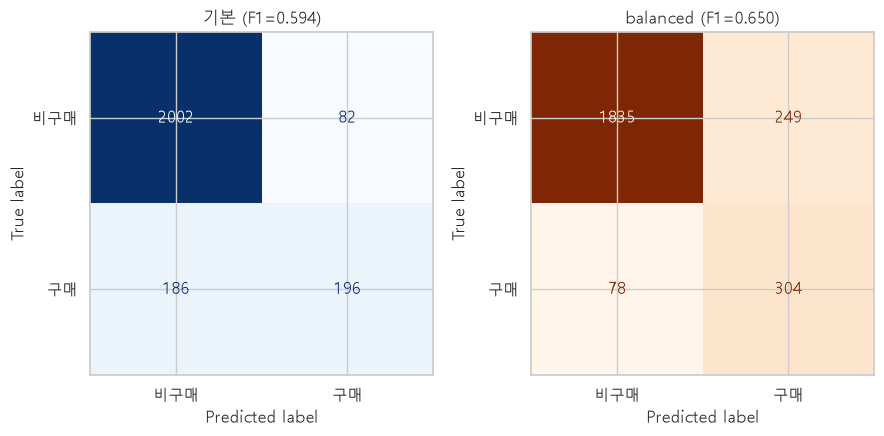

In [7]:
# ─────────────────────────────────────────────
# [C6] ⚖️ class_weight="balanced" 적용 → 비교 → 혼동행렬 변화
# ─────────────────────────────────────────────

# 1) class_weight="balanced"로 교차검증 지표 5종 재측정 --------------------
rf_bal = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                class_weight="balanced",
                                random_state=RANDOM_STATE, n_jobs=-1)

cv_res_bal = cross_validate(rf_bal, X, y, cv=cv, scoring=SCORING,
                            return_train_score=True, n_jobs=-1)

print("── class_weight='balanced' 5-Fold 교차검증 ──────────")
for name in SCORING:
    te = cv_res_bal[f"test_{name}"]
    print(f"{name:<20}{te.mean():.4f} ± {te.std():.4f}")

# 참고: class_weight가 실제로 어떻게 계산됐는지 확인
n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
w_neg = len(y) / (2 * n_neg)
w_pos = len(y) / (2 * n_pos)
print(f"\n(참고) balanced 가중치: 음성(비구매)={w_neg:.4f}, 양성(구매)={w_pos:.4f}")
print(f"       → 양성 1건이 음성 {w_pos/w_neg:.2f}건만큼의 무게로 학습됩니다")

# 2) 기본 설정 vs balanced 나란히 비교 ---------------------------------
compare_cv = pd.DataFrame({
    "지표": list(SCORING.keys()),
    "기본_평균":     [cv_res[f"test_{m}"].mean() for m in SCORING],
    "기본_표준편차": [cv_res[f"test_{m}"].std()  for m in SCORING],
    "balanced_평균":     [cv_res_bal[f"test_{m}"].mean() for m in SCORING],
    "balanced_표준편차": [cv_res_bal[f"test_{m}"].std()  for m in SCORING],
})
compare_cv["변화"] = compare_cv["balanced_평균"] - compare_cv["기본_평균"]

print("\n── 기본 vs balanced 비교 (교차검증) ──────────────────")
print(compare_cv.to_string(index=False, float_format="%.4f"))

# 3) 홀드아웃 혼동행렬로 TP·FN 변화 직접 확인 ---------------------------
# [C2]에서 만든 X_tr/X_te/y_tr/y_te를 그대로 재사용 (동일 분할이라 공정 비교)
rf_bal_holdout = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                        class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1)
rf_bal_holdout.fit(X_tr, y_tr)
y_pred_bal = rf_bal_holdout.predict(X_te)

cm_bal = confusion_matrix(y_te, y_pred_bal, labels=[0, 1])
tn_b, fp_b, fn_b, tp_b = cm_bal.ravel()

print("\n── 홀드아웃 혼동행렬 비교 (기본 vs balanced) ─────────")
print(f"{'':<10}{'기본':>10}{'balanced':>10}{'변화':>10}")
print(f"{'TN':<10}{tn:>10,d}{tn_b:>10,d}{tn_b-tn:>+10,d}")
print(f"{'FP':<10}{fp:>10,d}{fp_b:>10,d}{fp_b-fp:>+10,d}")
print(f"{'FN':<10}{fn:>10,d}{fn_b:>10,d}{fn_b-fn:>+10,d}")
print(f"{'TP':<10}{tp:>10,d}{tp_b:>10,d}{tp_b-tp:>+10,d}")

print(f"\n정밀도 : {precision_score(y_te, y_pred):.4f} → {precision_score(y_te, y_pred_bal):.4f}")
print(f"재현율 : {recall_score(y_te, y_pred):.4f} → {recall_score(y_te, y_pred_bal):.4f}")
print(f"F1     : {f1_score(y_te, y_pred):.4f} → {f1_score(y_te, y_pred_bal):.4f}")

# (보너스) 두 혼동행렬을 나란히 시각화
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["비구매", "구매"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"기본 (F1={f1_score(y_te, y_pred):.3f})")

ConfusionMatrixDisplay(cm_bal, display_labels=["비구매", "구매"]).plot(
    ax=axes[1], cmap="Oranges", colorbar=False)
axes[1].set_title(f"balanced (F1={f1_score(y_te, y_pred_bal):.3f})")
plt.tight_layout(); plt.show()

### 인과관계가 아니라 시소라고 생각하면 편함
- 임계값은 어디를 잘라야 하는지 알려주는 지표이고 가중치는 실제 조정을 하는 지표이다.
- 가중치를 주자 f1-score와 재현율은 올랐고 정밀도는 떨어졌다
- **핵심 근거**: AP(0.7248→0.7176)와 ROC-AUC(0.9091→0.9094)는
  표준편차 범위 내에서 사실상 불변 → 모델의 판별력(ranking) 자체는
  개선되지 않았고, 단지 임계값 0.5 지점에서의 트레이드오프 지점만 이동함

In [8]:
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

save_path = OUTPUT_DIR / "threshold_sweep.csv"
sweep.to_csv(save_path, index=False, encoding="utf-8-sig")

print(f"저장 완료: {save_path.resolve()}")
print(f"행 개수: {len(sweep)}개")
# 비교표도 같이 저장하고 싶다면
compare.to_csv(OUTPUT_DIR / "threshold_comparison.csv", index=False, encoding="utf-8-sig")

저장 완료: C:\Users\spide\ai-data-bootcamp\D20\output\threshold_sweep.csv
행 개수: 13개
